# Notebook 01 — Introdução ao Deep Learning

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- reconhecer o papel de NumPy, Pandas, Matplotlib e TensorFlow;
- representar um problema supervisionado com entradas e saídas;
- criar e treinar um modelo linear simples com Keras;
- observar como pesos e bias mudam durante o treinamento.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


## 1. NumPy: dados numéricos

O **NumPy** fornece arrays eficientes para cálculos matemáticos. A variável `numeros` será um vetor unidimensional com cinco valores. Em Deep Learning, entradas, pesos, ativações e previsões são representados por estruturas semelhantes.


In [3]:
import numpy as np

numeros = np.array([1, 2, 3, 4, 5])

print(numeros)

[1 2 3 4 5]


### Calculando uma estatística

`np.mean` calcula a média aritmética dos elementos. Estatísticas descritivas ajudam a conhecer a escala e a distribuição dos dados antes do treinamento.


In [4]:
print("Média:", np.mean(numeros))

Média: 3.0


## 2. Pandas: dados tabulares

O **Pandas** organiza dados em tabelas chamadas `DataFrame`. Cada chave do dicionário se torna uma coluna e cada posição das listas forma uma linha.


In [5]:
import pandas as pd

dados = {
    "nome": ["Igor", "Giovana", "Pedrette"],
    "idade": [25, 24, 30]
}

df = pd.DataFrame(dados)

df

,nome,idade
0,Igor,25
1,Giovana,24
2,Pedrette,30


## 3. Matplotlib: visualização

O gráfico de barras permite comparar as idades. Visualizar dados é importante para identificar padrões, diferenças de escala e possíveis problemas antes de construir um modelo.


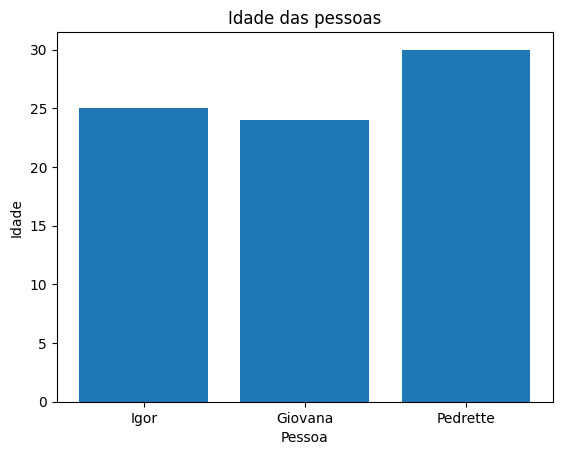

In [6]:
import matplotlib.pyplot as plt

idades = [25, 24, 30]
nomes = ["Igor", "Giovana", "Pedrette"]

plt.bar(nomes, idades)

plt.title("Idade das pessoas")
plt.xlabel("Pessoa")
plt.ylabel("Idade")

plt.show()

## 4. TensorFlow

O TensorFlow é a biblioteca que usaremos para construir e treinar redes neurais. Conferir a versão ajuda a documentar o ambiente utilizado.


In [7]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


### Verificando aceleração por GPU

A GPU pode acelerar treinamentos grandes. Neste exemplo pequeno, uma CPU é suficiente. Uma lista vazia não representa erro; significa apenas que nenhuma GPU foi disponibilizada ao ambiente.


In [8]:
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

GPU disponível: []


## 5. Criando um problema supervisionado

As entradas são armazenadas em `x` e as respostas corretas em `y`. Os pares seguem a relação aproximada **y = 2x + 1**. O modelo não receberá essa fórmula: deverá aprendê-la observando os exemplos.


In [14]:
import numpy as np

x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([3, 5, 7, 9, 11, 13], dtype=float)

print("Entrada:", x)
print("Saída:", y)

Entrada: [1. 2. 3. 4. 5. 6.]
Saída: [ 3.  5.  7.  9. 11. 13.]


## 6. Primeiro modelo com Keras

`Sequential` cria uma sequência de camadas. A camada `Dense(units=1)` possui um único neurônio, adequado para prever um valor numérico.

- `input_shape=[1]`: cada exemplo possui uma característica;
- `optimizer="sgd"`: aplica Gradient Descent;
- `loss="mean_squared_error"`: mede o erro quadrático médio;
- `epochs=100`: percorre o conjunto de dados cem vezes.


In [16]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])
modelo.compile(
    optimizer="sgd",
    loss="mean_squared_error"
)
modelo.fit(
    x,
    y,
    epochs=500,
    verbose=0
)
resultado = modelo.predict(np.array([10.0]))

print(resultado)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[21.147715]]


### Pesos aprendidos

`get_weights()` retorna uma lista com o peso e o bias da camada. Para a relação esperada, o peso deve se aproximar de `2` e o bias de `1`, embora pequenas diferenças sejam normais.


In [17]:
print(modelo.get_weights())

[array([[2.0258298]], dtype=float32), array([0.88941735], dtype=float32)]


### Separando peso e bias

O primeiro item contém a matriz de pesos; o segundo contém o vetor de biases. Mesmo uma rede com apenas um neurônio usa essas estruturas.


In [18]:
pesos = modelo.get_weights()

print("Peso:", pesos[0])
print("Bias:", pesos[1])

Peso: [[2.0258298]]
Bias: [0.88941735]


## 7. Observando o aprendizado passo a passo

Criamos outro modelo para comparar seus parâmetros **antes** e **depois** do treinamento. `tf.keras.Input` declara explicitamente o formato da entrada e evita avisos recentes do Keras.


In [19]:
modelo_novo = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])

modelo_novo.compile(
    optimizer="sgd",
    loss="mean_squared_error"
)

### Estado inicial

Antes do treinamento, o peso é inicializado de maneira aleatória e o bias geralmente começa em zero. Esses valores ainda não representam a relação dos dados.


In [20]:
print("Antes do treinamento:")
print(modelo_novo.get_weights())

Antes do treinamento:
[array([[-1.4645431]], dtype=float32), array([0.], dtype=float32)]


### Treinando por uma época

Uma época corresponde a uma passagem completa pelos exemplos de treinamento. Após uma época, o otimizador já modifica os parâmetros, mas o modelo provavelmente ainda estará distante da solução.


In [21]:
modelo_novo.fit(
    x,
    y,
    epochs=1,
    verbose=0
)

### Conferindo a primeira atualização

A diferença em relação aos valores iniciais confirma que ocorreu aprendizado: o cálculo da loss produziu gradientes, e o SGD atualizou peso e bias.


In [22]:
print("Depois de 1 época:")
print(modelo_novo.get_weights())

Depois de 1 época:
[array([[-0.34363163]], dtype=float32), array([0.262518], dtype=float32)]


### Continuando o treinamento

Ao executar mais cem épocas, o modelo repete o ciclo **previsão → erro → gradientes → atualização**. A tendência é aproximar seus parâmetros da função que gerou os dados.


In [23]:
modelo_novo.fit(
    x,
    y,
    epochs=100,
    verbose=0
)

### Resultado final dos parâmetros

Compare estes valores com os anteriores. O importante não é obter exatamente `2` e `1`, mas observar a aproximação progressiva e a redução do erro.


In [24]:
print("Depois de mais 100 épocas:")
print(modelo_novo.get_weights())

Depois de mais 100 épocas:
[array([[2.0292056]], dtype=float32), array([0.8749652], dtype=float32)]


## 🧠 Conclusão

Neste primeiro contato, usamos quatro bibliotecas importantes e treinamos um modelo com apenas um neurônio. Observamos que o conhecimento do modelo fica armazenado em seus **pesos** e **bias**.

### Exercícios

1. Altere os dados para representar `y = 3x + 2` e treine um novo modelo.
2. Compare os pesos após 1, 10 e 100 épocas.
3. Use `modelo.predict(np.array([10.0]))` e compare com o valor esperado.

### Próximo notebook

No Notebook 02, estudaremos as estruturas matemáticas usadas por redes neurais: escalares, vetores, matrizes e tensores.
